<a href="https://colab.research.google.com/github/yuanjiayiy/verl_rl2f/blob/main/verification_vlm_eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title 1. Import
import json
import os
import random
import re
import time
import datetime
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from google import genai
from google.genai import types
from google.colab import drive, userdata
from IPython.display import display, Markdown

from openai import OpenAI
import base64

# Mount Google Drive
drive.mount('/content/drive')

# Gemini API Configuration
GEMINI_API_KEY = userdata.get("GEMINI_API_tier1")
GEMINI_CLIENT = genai.Client(api_key=GEMINI_API_KEY)

# OpenAI Configuration
OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")
OPENAI_CLIENT = OpenAI(api_key=OPENAI_API_KEY)

ValueError: mount failed

In [ ]:
# @title Load Data

def load_events_csv(csv_path):
    """
    Load events from CSV file.
    Expected columns: index, event_id, region, location_type, num_stations, expert_label
    """
    df = pd.read_csv(csv_path)

    # Validate required columns
    required_cols = ['index', 'event_id']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    print(f"📊 Loaded {len(df)} events from CSV")
    print(f"   Columns: {list(df.columns)}")

    if 'expert_majority_vote_label' in df.columns:
        print(f"\n   Label distribution:")
        print(df['expert_majority_vote_label'].value_counts().to_string())

    if 'expert_seismic_event_type' in df.columns:
        print(f"\n   Event distribution:")
        print(df['expert_seismic_event_type'].value_counts().to_string())

    return df


In [ ]:
# @title Utility Functions

def get_event_images(base_dir, index, event_id):
    """
    Get all image paths for an event.

    Waveform plots: {index}_{event_id}_moveout_XXX.png
    Map: {index}_{event_id}_map.png
    """
    prefix = f"{index}_{event_id}"

    # Find all matching images
    image_files = sorted(Path(base_dir).glob(f"{prefix}*.png"))

    if not image_files:
        return None, []

    # Separate map and moveout images
    map_image = None
    moveout_images = []

    for img_path in image_files:
        if '_map.png' in str(img_path):
            map_image = img_path
        elif '_moveout_' in str(img_path):
            moveout_images.append(img_path)

    return map_image, moveout_images


def build_few_shot_examples(base_dir, examples_config):
    """
    Build few-shot examples list using get_event_images.

    Args:
        base_dir (str): Base directory containing images
        examples_config (list): List of dicts with:
            - 'index': event index
            - 'event_id': event ID
            - 'text': explanation text for the example

    Returns:
        list: Few-shot examples with image_paths populated
    """
    few_shot_examples = []

    for config in examples_config:
        index = config['index']
        event_id = config['event_id']
        text = config['text']

        # Get images using existing function
        map_image, moveout_images = get_event_images(base_dir, index, event_id)

        # Combine all images (map first if available, then moveout plots)
        image_paths = []
        if map_image:
            image_paths.append(str(map_image))
        image_paths.extend([str(p) for p in moveout_images])

        if not image_paths:
            print(f"  ⚠️  Warning: No images found for few-shot example {index}_{event_id}")
            continue

        few_shot_examples.append({
            "text": text,
            "image_paths": image_paths
        })

    print(f"✅ Built {len(few_shot_examples)} few-shot examples")
    return few_shot_examples


def call_gemini_for_verification(
    image_paths,
    prompt_text,
    model_name="gemini-3-pro-preview",
    thinking_budget=-1,
    few_shot_examples=None,
    max_retries=3
):
    """
    Calls Gemini model with multiple images and prompt, supporting few-shot examples.

    Args:
        image_paths (list): List of paths to image files
        prompt_text (str): The text prompt
        model_name (str): Model name to use
        thinking_budget (int): Thinking budget (-1 for unlimited)
        few_shot_examples (list, optional): List of few-shot examples, each dict with:
            - 'text': explanation text for the example
            - 'image_paths': list of image paths for this example
        max_retries (int): Maximum number of retry attempts

    Returns:
        tuple: (response_text, token_usage_dict, error_message)
    """
    for attempt in range(max_retries):
        try:
            client = genai.Client(
                api_key=GEMINI_API_KEY,
                http_options={'api_version': 'v1alpha'}
            )

            # Build content parts
            content_parts = [types.Part(text=prompt_text)]

            # Add few-shot examples (interleaved text and images)
            if few_shot_examples:
                for i, example in enumerate(few_shot_examples):
                    # Add example explanation text
                    if 'text' in example:
                        content_parts.append(
                            types.Part(text=f"\n--- Example {i+1} ---\n{example['text']}")
                        )
                    # Add example images
                    if 'image_paths' in example:
                        for img_path in example['image_paths']:
                            with open(img_path, 'rb') as f:
                                image_bytes = f.read()

                            content_parts.append(
                                types.Part.from_bytes(
                                    data=image_bytes,
                                    mime_type='image/png',
                                    media_resolution=types.MediaResolution.MEDIA_RESOLUTION_MEDIUM
                                )

                            )

                # Add separator before actual query
                content_parts.append(
                    types.Part(text="\n--- Now review the following event ---\n")
                )

            # Add all query images
            for img_path in image_paths:
                with open(img_path, 'rb') as f:
                    image_bytes = f.read()

                content_parts.append(
                    types.Part.from_bytes(
                        data=image_bytes,
                        mime_type='image/png'
                    )

                )

            # Generate response
            response = client.models.generate_content(
                model=model_name,
                contents=[types.Content(parts=content_parts)],
                config=types.GenerateContentConfig(
                    thinking_config=types.ThinkingConfig(thinking_budget=thinking_budget)
                ),
            )

            model_answer = response.text
            usage = response.usage_metadata

            token_usage = {
                "total_token_count": usage.total_token_count,
                "input_tokens": usage.prompt_token_count,
                "output_tokens": usage.candidates_token_count,
            }

            return model_answer, token_usage, None

        except Exception as e:
            print(f"  ⚠️  API error (attempt {attempt + 1}/{max_retries}): {e}")
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)  # Exponential backoff
            else:
                return None, None, str(e)


def call_openai_for_verification(
    image_paths,
    prompt_text,
    model_name="gpt-5.2",
    few_shot_examples=None,
    max_retries=3
):
    """
    Calls OpenAI model with multiple images and prompt, supporting few-shot examples.

    Args:
        image_paths (list): List of paths to image files
        prompt_text (str): The text prompt
        model_name (str): Model name to use (e.g., "gpt-4.1", "gpt-4o")
        few_shot_examples (list, optional): List of few-shot examples, each dict with:
            - 'text': explanation text for the example
            - 'image_paths': list of image paths for this example
        max_retries (int): Maximum number of retry attempts

    Returns:
        tuple: (response_text, token_usage_dict, error_message)
    """
    import base64
    from openai import OpenAI

    def encode_image(image_path):
        with open(image_path, "rb") as image_file:
            return base64.b64encode(image_file.read()).decode("utf-8")

    for attempt in range(max_retries):
        try:
            client = OpenAI(api_key=OPENAI_API_KEY)

            # Build content parts for user message
            content_parts = []

            # Add the main prompt text first
            content_parts.append({"type": "input_text", "text": prompt_text})

            # Add few-shot examples (interleaved text and images)
            if few_shot_examples:
                for i, example in enumerate(few_shot_examples):
                    # Add example explanation text
                    if 'text' in example:
                        content_parts.append({
                            "type": "input_text",
                            "text": f"\n--- Example {i+1} ---\n{example['text']}"
                        })
                    # Add example images
                    if 'image_paths' in example:
                        for img_path in example['image_paths']:
                            base64_image = encode_image(img_path)
                            content_parts.append({
                                "type": "input_image",
                                "image_url": f"data:image/png;base64,{base64_image}",
                            })

                # Add separator before actual query
                content_parts.append({
                    "type": "input_text",
                    "text": "\n--- Now review the following event ---\n"
                })

            # Add all query images
            for img_path in image_paths:
                base64_image = encode_image(img_path)
                content_parts.append({
                    "type": "input_image",
                    "image_url": f"data:image/png;base64,{base64_image}",
                })

            # Generate response
            response = client.responses.create(
                model=model_name,
                input=[
                    {
                        "role": "user",
                        "content": content_parts,
                    }
                ],
            )

            model_answer = response.output_text
            usage = response.usage

            token_usage = {
                "total_token_count": usage.total_tokens,
                "input_tokens": usage.input_tokens,
                "output_tokens": usage.output_tokens,
            }

            return model_answer, token_usage, None

        except Exception as e:
            print(f"  ⚠️  OpenAI API error (attempt {attempt + 1}/{max_retries}): {e}")
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)  # Exponential backoff
            else:
                return None, None, str(e)


def parse_verdict(response_text):
    """
    Parse the VERDICT from LLM response.

    Looks for text after "**VERDICT:**" and extracts the verdict.
    Returns lowercase verdict string.
    """
    if not response_text:
        return None

    # Pattern to match **VERDICT:** followed by the verdict text
    patterns = [
        r'\*\*VERDICT:\*\*\s*([^\n*]+)',  # **VERDICT:** TEXT
        r'VERDICT:\s*([^\n*]+)',           # VERDICT: TEXT (without bold)
        r'\*\*VERDICT\*\*:\s*([^\n*]+)',   # **VERDICT**: TEXT
    ]

    for pattern in patterns:
        match = re.search(pattern, response_text, re.IGNORECASE)
        if match:
            verdict = match.group(1).strip()
            # Clean up the verdict (remove brackets, extra punctuation)
            verdict = re.sub(r'[\[\]]', '', verdict)
            verdict = verdict.strip()

            # Extract only the first two words
            words = verdict.lower().split()
            if len(words) >= 2:
                return ' '.join(words[:2])
            elif len(words) == 1:
                return words[0]

    return None


def parse_seismic_event_type(response_text):
    """
    Parse the SEISMIC_EVENT_TYPE from LLM response.

    Looks for text after "**SEISMIC_EVENT_TYPE:**" or similar patterns.
    Returns lowercase event type string.
    """
    if not response_text:
        return None

    # Pattern to match **SEISMIC_EVENT_TYPE:** or **Event Type:** followed by the type
    patterns = [
        r'\*\*SEISMIC[_\s]?EVENT[_\s]?TYPE:\*\*\s*([^\n*]+)',  # **SEISMIC_EVENT_TYPE:** TEXT
        r'SEISMIC[_\s]?EVENT[_\s]?TYPE:\s*([^\n*]+)',           # SEISMIC_EVENT_TYPE: TEXT
        r'\*\*SEISMIC[_\s]?EVENT[_\s]?TYPE\*\*:\s*([^\n*]+)',  # **SEISMIC_EVENT_TYPE**: TEXT
    ]

    for pattern in patterns:
        match = re.search(pattern, response_text, re.IGNORECASE)
        if match:
            event_type = match.group(1).strip()
            # Clean up (remove brackets, extra punctuation)
            event_type = re.sub(r'[\[\]]', '', event_type)
            event_type = event_type.strip()

            words = event_type.lower().split()
            return words[0]

    return None


def compute_score(model_parsed, ground_truth):
    """
    Compute score by comparing parsed verdict with expert label.
    Both are converted to lowercase for comparison.

    Returns:
        1 if match, 0 if no match, None if verdict couldn't be parsed
    """
    if model_parsed is None:
        return None

    gt_lower = str(ground_truth).lower().strip()

    # Check for match
    return 1 if model_parsed == gt_lower else 0


In [ ]:
# @title Process Single Event

def process_single_event(
    event_row,
    base_dir,
    model_name,
    thinking_budget,
    results_dir,
    few_shot_examples=None,
    force_rerun=False
):
    """
    Process a single event for verification.

    Args:
        event_row (pd.Series): Row from events DataFrame
        base_dir (str): Base directory containing images
        model_name (str): Model name to use
        thinking_budget (int): Thinking budget for the model (Gemini only)
        results_dir (str): Directory to save results
        few_shot_examples (list, optional): List of few-shot examples for the prompt
        force_rerun (bool): If True, reprocess even if result exists

    Returns:
        dict: Result dictionary with status, scores, etc.
    """
    idx = event_row['index']
    event_id = event_row['event_id']
    human_label = event_row['expert_majority_vote_label']

    # Create output directory for this model
    output_dir = os.path.join(results_dir, model_name)
    os.makedirs(output_dir, exist_ok=True)

    result_path = os.path.join(output_dir, f"{idx}_{event_id}_result.json")

    # Skip if already processed
    if os.path.exists(result_path) and not force_rerun:
        return {"status": "skipped", "index": idx, "event_id": event_id}

    try:
        # Add small delay to avoid rate limiting
        time.sleep(random.uniform(0.1, 0.5))

        # Get images for this event
        map_image, moveout_images = get_event_images(base_dir, idx, event_id)

        if not moveout_images:
            return {
                "status": "error",
                "index": idx,
                "event_id": event_id,
                "error": "No images found"
            }

        # Combine all images (map first if available, then moveout plots)
        all_images = []
        if map_image:
            all_images.append(map_image)
        all_images.extend(moveout_images)

        # Call appropriate API based on model name
        if model_name.lower().startswith('gemini'):
            response_text, token_usage, error = call_gemini_for_verification(
                all_images,
                VERIFICATION_PROMPT,
                model_name,
                thinking_budget,
                few_shot_examples=few_shot_examples
            )
        elif model_name.lower().startswith('gpt'):
            response_text, token_usage, error = call_openai_for_verification(
                all_images,
                VERIFICATION_PROMPT,
                model_name,
                few_shot_examples=few_shot_examples
            )
        else:
            return {
                "status": "error",
                "index": idx,
                "event_id": event_id,
                "error": f"Unknown model type: {model_name}. Must start with 'gemini' or 'gpt'."
            }

        if error:
            return {
                "status": "error",
                "index": idx,
                "event_id": event_id,
                "error": error
            }

        # Parse verdict
        parsed_verdict = parse_verdict(response_text)

        # Parse seismic event type from model response
        parsed_event_type = parse_seismic_event_type(response_text)

        # Compute label_score (verdict vs human_label)
        label_score = compute_score(parsed_verdict, human_label)

        # Compute seismic_event_type_score
        # Only applicable when human_label is "true seismic", otherwise N/A
        human_label_lower = str(human_label).lower().strip()
        if human_label_lower == "true seismic":
            expert_event_type = event_row.get('expert_event_type')
            seismic_event_type_score = compute_score(parsed_event_type, expert_event_type)
        else:
            expert_event_type = None
            seismic_event_type_score = "N/A"

        # Create result dictionary
        result = {
            "index": idx,
            "event_id": event_id,
            "model_name": model_name,
            "human_label": human_label,
            "parsed_verdict": parsed_verdict,
            "label_score": label_score,

            "expert_event_type": expert_event_type,
            "parsed_event_type": parsed_event_type,
            "seismic_event_type_score": seismic_event_type_score,

            "token_usage": token_usage,
            "images_used": [str(p) for p in all_images],
            # Include additional metadata if available
            "region": event_row.get('region'),
            "location_type": event_row.get('location_type'),
            "num_stations": event_row.get('num_stations'),

            "model_response_raw": response_text,
        }

        # Save result
        with open(result_path, 'w') as f:
            json.dump(result, f, indent=2)

        return {
            "status": "success",
            "index": idx,
            "event_id": event_id,
            "label_score": label_score,
            "seismic_event_type_score": seismic_event_type_score,
            "parsed_verdict": parsed_verdict,
            "parsed_event_type": parsed_event_type
        }

    except Exception as e:
        print(f"  ❌ Error processing {idx}_{event_id}: {e}")
        return {
            "status": "error",
            "index": idx,
            "event_id": event_id,
            "error": str(e)
        }

In [ ]:
# @title Run Evaluation (Parallel)

def run_evaluation_parallel(
    gt_df,
    base_dir,
    models_to_test,
    thinking_budget,
    results_dir,
    max_workers=4,
    max_events=None,
    few_shot_examples=None,
    force_rerun=False
):
    """
    Run evaluation across all models and events in parallel.

    Args:
        gt_df (pd.DataFrame): DataFrame with event data
        base_dir (str): Base directory containing images
        models_to_test (list): List of model names
        thinking_budget (int): Thinking budget for models
        results_dir (str): Directory to save results
        max_workers (int): Number of parallel workers
        max_events (int, optional): Limit number of events to process
        force_rerun (bool): If True, reprocess existing results
    """
    # Limit events if specified
    if max_events is not None:
        events_subset = gt_df.head(max_events)
        print(f"\n⚠️  Running on first {max_events} events (out of {len(gt_df)} total)")
    else:
        events_subset = gt_df
        print(f"\n📊 Running on all {len(gt_df)} events")

    all_results = {}

    for model_name in models_to_test:
        print(f"\n{'='*60}")
        print(f"🧪 Processing Model: {model_name}")
        print(f"{'='*60}")

        model_results = []

        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            futures = []

            for _, row in events_subset.iterrows():
                future = executor.submit(
                    process_single_event,
                    row,
                    base_dir,
                    model_name,
                    thinking_budget,
                    results_dir,
                    few_shot_examples,
                    force_rerun
                )
                futures.append(future)

            # Collect results with progress
            completed = 0
            errors = 0
            skipped = 0
            total_score = 0
            scored_count = 0

            for future in as_completed(futures):
                try:
                    result = future.result()
                    model_results.append(result)

                    if result['status'] == 'success':
                        completed += 1
                        if result['label_score'] is not None:
                            total_score += result['label_score']
                            scored_count += 1
                    elif result['status'] == 'error':
                        errors += 1
                    elif result['status'] == 'skipped':
                        skipped += 1

                except Exception as exc:
                    print(f"  ❌ Exception: {exc}")
                    errors += 1

        # Print summary for this model
        print(f"\n✅ {model_name} completed:")
        print(f"   - Processed: {completed}")
        print(f"   - Skipped: {skipped}")
        print(f"   - Errors: {errors}")
        if scored_count > 0:
            accuracy = total_score / scored_count * 100
            print(f"   - Accuracy: {accuracy:.2f}% ({total_score}/{scored_count})")

        all_results[model_name] = model_results

    return all_results


### Configuration

In [ ]:
# === PATH CONFIGURATION ===
BASE_DIR = '/content/drive/Shareddrives/AgentSeismo/verification/human_dataset/figures'

# current_time = datetime.now().strftime("%Y%m%d_%H%M")
# RESULTS_DIR = os.path.join(Path(BASE_DIR).parent, f'results_{current_time}')

RESULTS_DIR = os.path.join(Path(BASE_DIR).parent, f'results_20260218_0702')
print(f"RESULTS_DIR: {RESULTS_DIR}")

# === Load Expert Spreadsheets ===
gt_path = "https://docs.google.com/spreadsheets/d/1D9E0iPZQUYDp90_u14mhx7FrL9UMDry4jy9hhY7SgvU/export?format=csv&gid=527490902"

gt_df = load_events_csv(gt_path)

display(gt_df.head())

RESULTS_DIR: /content/drive/Shareddrives/AgentSeismo/verification/human_dataset/results_20260218_0702
📊 Loaded 200 events from CSV
   Columns: ['index', 'event_id', 'num_picks', 'num_stations', 'region', 'location_type', 'expert_1_label', 'expert_1_seismic_event_type', 'expert_2_label', 'expert_2_seismic_event_type', 'expert_3_label', 'expert_3_seismic_event_type', 'expert_majority_vote_label', 'expert_event_type', 'event_latitude_deg', 'event_longitude_deg', 'event_depth_km']

   Label distribution:
expert_majority_vote_label
True Seismic      102
False Positive     98


,index,event_id,num_picks,num_stations,region,location_type,expert_1_label,expert_1_seismic_event_type,expert_2_label,expert_2_seismic_event_type,expert_3_label,expert_3_seismic_event_type,expert_majority_vote_label,expert_event_type,event_latitude_deg,event_longitude_deg,event_depth_km
0,1,11951,16,8,PNW,onshore,False Positive,NaN,False Positive,NaN,False Positive,NaN,False Positive,NaN,42.611661,-111.702849,0.390625
1,2,32689,22,16,PNW,onshore,False Positive,NaN,False Positive,NaN,True Seismic,non-earthquake,False Positive,NaN,41.662749,-112.358381,0.390625
2,3,39761,9,6,PNW,onshore,False Positive,NaN,False Positive,NaN,False Positive,NaN,False Positive,NaN,42.842725,-118.309425,0.390625
3,4,48857,15,12,PNW,onshore,False Positive,NaN,False Positive,NaN,False Positive,NaN,False Positive,NaN,41.411801,-125.645165,0.390625
4,5,57174,26,21,PNW,onshore,True Seismic,earthquake,True Seismic,earthquake,True Seismic,non-earthquake,True Seismic,earthquake,45.085130,-122.496292,0.390625


In [ ]:
# @title Verification Prompt

# VERIFICATION_PROMPT = """You are a seismologist reviewing ML-detected and associated seismic events. Your goal is to identify ONLY HIGH-QUALITY TRUE seismic events suitable for inclusion in an official seismic catalog.

# **INPUT DATA:**
# - Move-out plots (Z, 1 or N, 2 or E components) with 1 Hz high-passed seismogram plots normalized on each waveform. No station responses are removed. RED triangles are ML-picked P-wave arrivals; BLUE triangles are ML-picked S-wave arrivals.
# - A location map showing station positions (blur triangles) and the inferred event location (red star). The reported origin time, latitude, longitude, depth, and epicentral distances are produced by an automated associator and can be WRONG.
# - IMPORTANT: The input picks are generated by automated algorithms. They often contain individual errors (false phase types, missing picks, or timing errors).

# ---
# **CLASSIFICATION CRITERIA:**

# 1. Waveform and Phase Pick
# - Clear seismic signals on multiple stations, consistent with a single source.
# - Do RED (P) and BLUE (S) picks align with visible phase onsets across waveforms?
# - Inaccurate P or S pick ⇒ FALSE POSITIVE, even if other seismic-like signals are visible.
# - Do NOT discard outlier stations or picks.

# 2. Association and Location
# - Picks must align with one coherent origin time.
# - Relative timing and moveout must be compatible with a single reported location.

# 3. Move-out Pattern
# - Clear, distance-dependent moveout must be visible across multiple stations.
# - As epicentral distance (x-axis) increases, do the red and blue picks form two distinct linear or smoothly varying trends (P shallower slope than S)?
# - Are apparent velocities physically reasonable to reflect the Earth's velocity structure?

# 4. Station Coverage and Geometry
# - Stations must span multiple epicentral distances.
# - Reasonable azimuthal distribution (small azimuthal gaps)
# - Dense clustering alone, poor geometry or insufficient stations ⇒ FALSE POSITIVE.

# If ANY criterion above is not satisfied, classify the event as FALSE POSITIVE.


# **CLASSIFICATION TASK:**

# Step 1: VERDICT
# - TRUE SEISMIC EVENT or FALSE POSITIVE

# Step 2: Event Type (ONLY if TRUE SEISMIC EVENT)
# - **Earthquake**: Tectonic rupture (fault slip), or volcanic events
# - **Non-earthquake**: Explosion/blast, avalanche, rockfall, landslide, locomotive, or other surface/anthropogenic sources
# - If FALSE POSITIVE, event type is N/A.

# ---

# **Output format:**
# - **VERDICT:** [TRUE SEISMIC / FALSE POSITIVE]
# - SEISMIC_EVENT_TYPE: [EARTHQUAKE / NON-EARTHQUAKE / N/A]
# - Reasoning: [concise, science-based explanation; or specific problems with picks, moveout, association, or geometry]
# """

VERIFICATION_PROMPT = """You are a seismologist reviewing ML-detected and associated seismic events. Your goal is to identify ONLY HIGH-QUALITY TRUE seismic events suitable for inclusion in an official seismic catalog.

**INPUT DATA:**
- Move-out plots (Z, 1 or N, 2 or E components) with 1 Hz high-passed seismogram plots normalized on each waveform. No station responses are removed. RED triangles are ML-picked P-wave arrivals; BLUE triangles are ML-picked S-wave arrivals.
- A location map showing station positions (blur triangles) and the inferred event location (red star). The reported origin time, latitude, longitude, depth, and epicentral distances are produced by an automated associator and can be WRONG.
- IMPORTANT: The input picks are generated by automated algorithms. They often contain individual errors (false phase types, missing picks, or timing errors).

---

**CLASSIFICATION TASK:**

Step 1: VERDICT
- TRUE SEISMIC EVENT or FALSE POSITIVE

Step 2: Event Type (ONLY if TRUE SEISMIC EVENT)
- **Earthquake**: Tectonic rupture (fault slip), or volcanic events
- **Non-earthquake**: Explosion/blast, avalanche, rockfall, landslide, locomotive, or other surface/anthropogenic sources
- If FALSE POSITIVE, event type is N/A.

---

**Output format:**
- **VERDICT:** [TRUE SEISMIC / FALSE POSITIVE]
- SEISMIC_EVENT_TYPE: [EARTHQUAKE / NON-EARTHQUAKE / N/A]
- Reasoning: [concise, science-based explanation; or specific problems with picks, moveout, association, or geometry]
"""

print(VERIFICATION_PROMPT)

You are a seismologist reviewing ML-detected and associated seismic events. Your goal is to identify ONLY HIGH-QUALITY TRUE seismic events suitable for inclusion in an official seismic catalog.

**INPUT DATA:**
- Move-out plots (Z, 1 or N, 2 or E components) with 1 Hz high-passed seismogram plots normalized on each waveform. No station responses are removed. RED triangles are ML-picked P-wave arrivals; BLUE triangles are ML-picked S-wave arrivals.
- A location map showing station positions (blur triangles) and the inferred event location (red star). The reported origin time, latitude, longitude, depth, and epicentral distances are produced by an automated associator and can be WRONG.
- IMPORTANT: The input picks are generated by automated algorithms. They often contain individual errors (false phase types, missing picks, or timing errors).

---

**CLASSIFICATION TASK:**

Step 1: VERDICT
- TRUE SEISMIC EVENT or FALSE POSITIVE

Step 2: Event Type (ONLY if TRUE SEISMIC EVENT)
- **Earthqua

In [ ]:
# @title Define few-shot examples
# few_shot_config = [
#     {
#         "index": 4,
#         "event_id": 48857,
#         "text": "**VERDICT:** FALSE POSITIVE\n\n**SEISMIC_EVENT_TYPE:** N/A\n\n**Issues identified:** It is highly possible that P waves are picked on noise. There is no clear and coherent move-out among shown stations, and there is limited station coverage at near offset. As such, this detection is most likely to be a false detection."
#     },
#     {
#         "index": 16,
#         "event_id": 63886,
#         "text": "**VERDICT:** TRUE SEISMIC\n\n**SEISMIC_EVENT_TYPE:** NON-EARTHQUAKE\n\n**Reasoning:** The P at 0.6 deg may be incorrectly picked, but waveforms are coherently observed at short offset. The P arrivals are not impulsively observed and the duration of the event seems longer than 20 seconds, supporting an non-earthquake event around Mt. St. Helens."
#     },
#     {
#         "index": 30,
#         "event_id": 64180,
#         "text": "**VERDICT:** FALSE POSITIVE\n\n**SEISMIC_EVENT_TYPE:** N/A\n\n**Issues identified:** This detection is made on stations around Mt. St. Helens. The waveforms are robust and coherent, with clear arrival signals. However, the waveforms feature strong low-frequency component, suggesting a far seismic event (teleseism) instead of a local Mt. St. Helens event. According to the classification policy, I label it as a false positive."
#     },
# ]

few_shot_config = [
    {
        "index": 4,
        "event_id": 48857,
        "text": "**VERDICT:** FALSE POSITIVE\n\n**SEISMIC_EVENT_TYPE:** N/A\n\n**Reasoning:** This is a FALSE POSITIVE. The ML-picked P arrivals are placed on random noise fluctuations rather than clear phase arrivals. There is no clear, distance-dependent moveout across stations. The station coverage is limited to a narrow near-offset range, insufficient to constrain a location."
    },
    {
        "index": 16,
        "event_id": 63886,
        "text": "**VERDICT:** TRUE SEISMIC\n\n**SEISMIC_EVENT_TYPE:** NON-EARTHQUAKE\n\n**Reasoning:** Although the P pick at ~0.6° may be mis-picked, waveforms are coherently observed across the remaining short-offset stations. The outlier is ignored because the majority of stations confirm a source.\nThe P arrivals are not impulsively observed, and the duration of the event exceeds 20 seconds, which supports a non-earthquake event at Mt. St. Helens."
    },
    {
        "index": 30,
        "event_id": 64180,
        "text": "**VERDICT:** FALSE POSITIVE\n\n**SEISMIC_EVENT_TYPE:** N/A\n\n**Reasoning:** This is a FALSE POSITIVE. The waveforms across stations near Mt. St. Helens are robust and coherent; however, the signals are dominated by strong low-frequency energy, which is more consistent with a distant (teleseismic) event than a local source. Because the moveout cannot be verified due to a narrow distance range (x-axis offset is less than 0.15°) and the frequency content contradicts a local event, incorrect association/location invalidates the event for catalog inclusion."
    },
]

# Build few-shot examples
few_shot_examples = build_few_shot_examples(BASE_DIR, few_shot_config)

✅ Built 3 few-shot examples


In [ ]:
# @title RUN evaluation

# === MODEL CONFIGURATION ===
MODELS_TO_TEST = [
    'gemini-3-flash-preview',
    'gemini-3-pro-preview',
    'gpt-5.2'
]

# Thinking budget for Gemini models (-1 for Default, 0 for Disable) https://ai.google.dev/gemini-api/docs/thinking
THINKING_BUDGET = -1

# === EXECUTION CONFIGURATION ===
MAX_WORKERS = 5  # Number of parallel workers
MAX_EVENTS = 200  # Set to None to process all events, or an integer to limit
FORCE_RERUN = False  # Set to True to reprocess already-completed events

# Create results directory
os.makedirs(RESULTS_DIR, exist_ok=True)

# Run evaluation
results = run_evaluation_parallel(
        gt_df=gt_df,
        base_dir=BASE_DIR,
        models_to_test=MODELS_TO_TEST,
        thinking_budget=THINKING_BUDGET,
        results_dir=RESULTS_DIR,
        max_workers=MAX_WORKERS,
        max_events=MAX_EVENTS,
        # few_shot_examples=few_shot_examples,  # Pass few-shot examples
        force_rerun=FORCE_RERUN
    )


⚠️  Running on first 200 events (out of 200 total)

🧪 Processing Model: gemini-3-flash-preview

✅ gemini-3-flash-preview completed:
   - Processed: 0
   - Skipped: 200
   - Errors: 0

🧪 Processing Model: gemini-3-pro-preview

✅ gemini-3-pro-preview completed:
   - Processed: 0
   - Skipped: 200
   - Errors: 0

🧪 Processing Model: gpt-5.2

✅ gpt-5.2 completed:
   - Processed: 5
   - Skipped: 195
   - Errors: 0
   - Accuracy: 100.00% (5/5)


### Analyze Results

In [ ]:
# @title Helper Functions
def load_results(results_dir, models=None, limit=None):
    """
    Load saved results from the results directory.

    Args:
        results_dir (str): Path to results directory
        models (list, optional): List of model names to load. If None, loads all.
        limit (int, optional): Max number of results to load per model. If None, loads all.

    Returns:
        pd.DataFrame: DataFrame with all results
    """
    all_results = []

    results_path = Path(results_dir)

    # Get model directories
    if models:
        model_dirs = [results_path / m for m in models if (results_path / m).exists()]
    else:
        model_dirs = [d for d in results_path.iterdir() if d.is_dir()]

    for model_dir in model_dirs:
        model_name = model_dir.name

        # Sort by the numeric index of the filename
        result_files = sorted(
            model_dir.glob("*_result.json"),
            key=lambda f: int(f.stem.split('_')[0])
        )

        if limit is not None:
            result_files = result_files[:limit]

        for result_file in result_files:
            with open(result_file, 'r') as f:
                result = json.load(f)
                all_results.append(result)

    if not all_results:
        print("⚠️  No results found")
        return pd.DataFrame()

    df = pd.DataFrame(all_results)
    limit_str = f" (limit: {limit}/model)" if limit else ""
    print(f"📊 Loaded {len(df)} results from {len(model_dirs)} model(s){limit_str}")

    return df


def compute_accuracy_summary(results_df):
    """
    Compute accuracy summary by model for both label_score and seismic_event_type_score.
    """
    if results_df.empty:
        return pd.DataFrame()

    # Filter to only scored results for label_score
    scored_df = results_df[results_df['label_score'].notna()].copy()

    summary = scored_df.groupby('model_name').agg(
        total_events=('label_score', 'count'),
        label_correct=('label_score', 'sum'),
        label_accuracy=('label_score', 'mean')
    ).reset_index()

    summary['label_accuracy'] = summary['label_accuracy'] * 100
    summary['label_accuracy_str'] = summary.apply(
        lambda x: f"{x['label_accuracy']:.2f}% ({int(x['label_correct'])}/{int(x['total_events'])})",
        axis=1
    )

    # Compute seismic_event_type_score accuracy (only for true seismic events)
    event_type_df = results_df[
        (results_df['seismic_event_type_score'].notna()) &
        (results_df['seismic_event_type_score'] != "N/A")
    ].copy()

    if not event_type_df.empty:
        event_type_df['seismic_event_type_score'] = event_type_df['seismic_event_type_score'].astype(float)
        event_type_summary = event_type_df.groupby('model_name').agg(
            event_type_total=('seismic_event_type_score', 'count'),
            event_type_correct=('seismic_event_type_score', 'sum'),
            event_type_accuracy=('seismic_event_type_score', 'mean')
        ).reset_index()

        event_type_summary['event_type_accuracy'] = event_type_summary['event_type_accuracy'] * 100
        event_type_summary['event_type_accuracy_str'] = event_type_summary.apply(
            lambda x: f"{x['event_type_accuracy']:.2f}% ({int(x['event_type_correct'])}/{int(x['event_type_total'])})",
            axis=1
        )

        # Merge summaries
        summary = summary.merge(
            event_type_summary[['model_name', 'event_type_accuracy_str']],
            on='model_name',
            how='left'
        )
    else:
        summary['event_type_accuracy_str'] = 'N/A'

    return summary


In [ ]:
BASE_DIR = '/content/drive/Shareddrives/AgentSeismo/verification/human_dataset/figures'

# RESULTS_DIR = os.path.join(Path(BASE_DIR).parent, f'results_{current_time}')
# RESULTS_DIR = '/content/drive/Shareddrives/AgentSeismo/verification/human_dataset/results_20260218_0438'
RESULTS_DIR = '/content/drive/Shareddrives/AgentSeismo/verification/human_dataset/results_20260218_0702'

# === MODEL CONFIGURATION ===
MODELS_TO_TEST = [
    'gemini-3-flash-preview',
    'gemini-3-pro-preview',
    'gpt-5.2',
]

# Load results
results_df = load_results(RESULTS_DIR, MODELS_TO_TEST, limit=200)

if not results_df.empty:
    # Compute summary
    summary_df = compute_accuracy_summary(results_df)

    print("\n" + "="*60)
    print("ACCURACY SUMMARY")
    print("="*60)
    display(summary_df[['model_name', 'label_accuracy_str', 'event_type_accuracy_str']])

📊 Loaded 600 results from 3 model(s) (limit: 200/model)

ACCURACY SUMMARY


,model_name,label_accuracy_str,event_type_accuracy_str
0,gemini-3-flash-preview,57.00% (114/200),77.45% (79/102)
1,gemini-3-pro-preview,57.00% (114/200),82.35% (84/102)
2,gpt-5.2,67.50% (135/200),54.90% (56/102)


In [ ]:
# results_df

VERDICT CONFUSION MATRICES


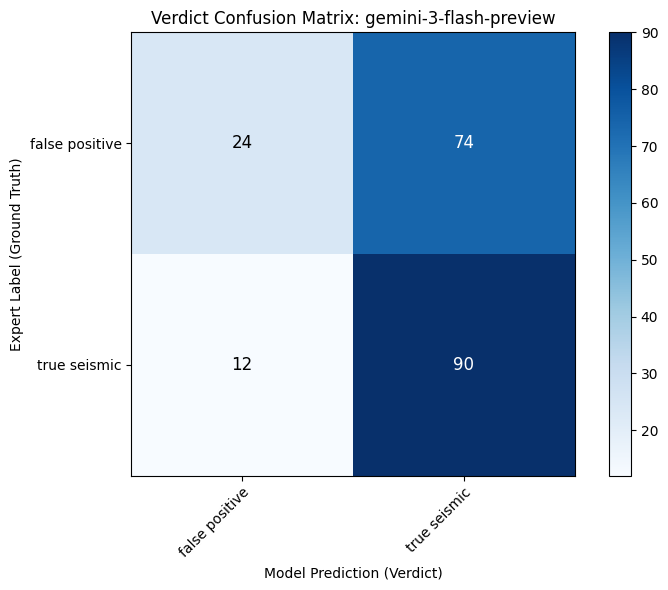


CLASSIFICATION REPORT (LABEL): gemini-3-flash-preview

Label                 Precision     Recall   F1-Score    Support
------------------------------------------------------------
false positive           66.67%     24.49%     35.82%         98
true seismic             54.88%     88.24%     67.67%        102
------------------------------------------------------------
Overall Accuracy                               57.00%        200



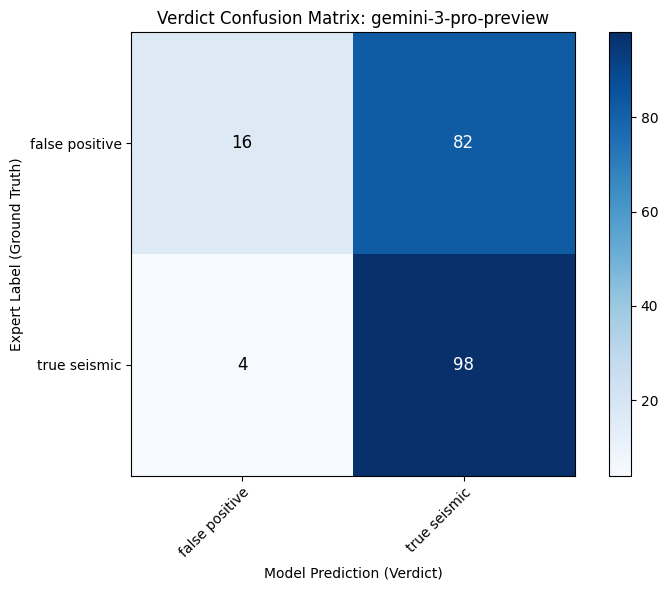


CLASSIFICATION REPORT (LABEL): gemini-3-pro-preview

Label                 Precision     Recall   F1-Score    Support
------------------------------------------------------------
false positive           80.00%     16.33%     27.12%         98
true seismic             54.44%     96.08%     69.50%        102
------------------------------------------------------------
Overall Accuracy                               57.00%        200



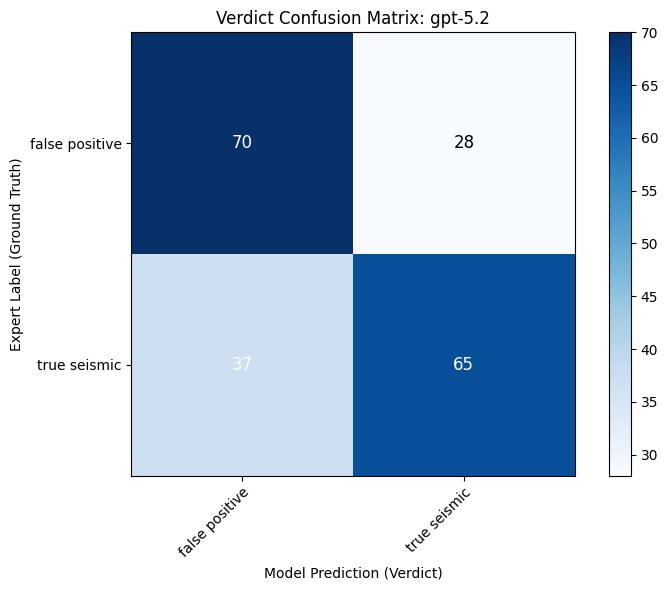


CLASSIFICATION REPORT (LABEL): gpt-5.2

Label                 Precision     Recall   F1-Score    Support
------------------------------------------------------------
false positive           65.42%     71.43%     68.29%         98
true seismic             69.89%     63.73%     66.67%        102
------------------------------------------------------------
Overall Accuracy                               67.50%        200


SEISMIC EVENT TYPE CONFUSION MATRICES


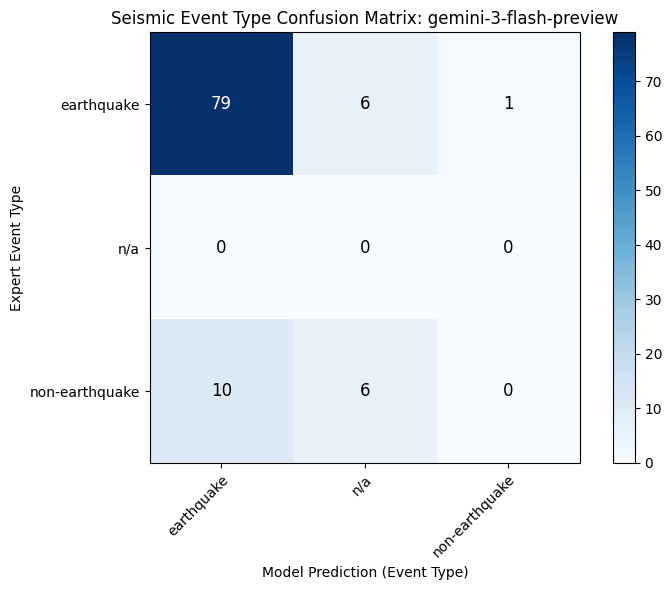


CLASSIFICATION REPORT (EVENT_TYPE): gemini-3-flash-preview

Label                 Precision     Recall   F1-Score    Support
------------------------------------------------------------
earthquake               88.76%     91.86%     90.29%         86
n/a                       0.00%      0.00%      0.00%          0
non-earthquake            0.00%      0.00%      0.00%         16
------------------------------------------------------------
Overall Accuracy                               77.45%        102



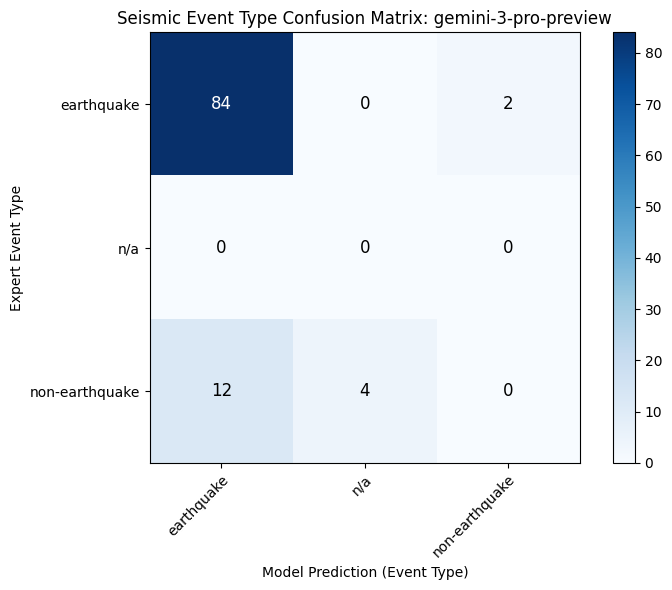


CLASSIFICATION REPORT (EVENT_TYPE): gemini-3-pro-preview

Label                 Precision     Recall   F1-Score    Support
------------------------------------------------------------
earthquake               87.50%     97.67%     92.31%         86
n/a                       0.00%      0.00%      0.00%          0
non-earthquake            0.00%      0.00%      0.00%         16
------------------------------------------------------------
Overall Accuracy                               82.35%        102



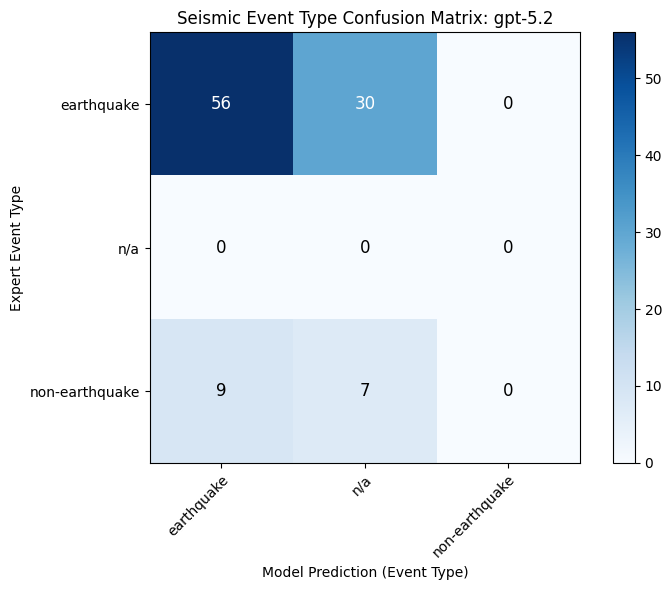


CLASSIFICATION REPORT (EVENT_TYPE): gpt-5.2

Label                 Precision     Recall   F1-Score    Support
------------------------------------------------------------
earthquake               86.15%     65.12%     74.17%         86
n/a                       0.00%      0.00%      0.00%          0
non-earthquake            0.00%      0.00%      0.00%         16
------------------------------------------------------------
Overall Accuracy                               54.90%        102



In [ ]:
# @title Confusion Matrix

import matplotlib.pyplot as plt

def plot_confusion_matrix_heatmap(results_df, model_name=None, normalize=False, score_type='label'):
    """
    Plot confusion matrix as a heatmap.

    Args:
        results_df (pd.DataFrame): Results DataFrame
        model_name (str, optional): Filter to specific model
        normalize (bool): If True, show percentages instead of counts
        score_type (str): 'label' for verdict confusion, 'event_type' for seismic event type confusion
    """
    if results_df.empty:
        print("⚠️  No results to plot")
        return

    scored_df = results_df[results_df['parsed_verdict'].notna()].copy()

    if model_name:
        scored_df = scored_df[scored_df['model_name'] == model_name]

    models = scored_df['model_name'].unique()

    for model in models:
        model_df = scored_df[scored_df['model_name'] == model]

        if score_type == 'label':
            # Verdict confusion matrix
            y_true = model_df['human_label'].str.lower().str.strip()
            y_pred = model_df['parsed_verdict'].str.lower().str.strip()
            title_prefix = "Verdict Confusion Matrix"
            ylabel = "Expert Label (Ground Truth)"
            xlabel = "Model Prediction (Verdict)"
        elif score_type == 'event_type':
            # Filter to only true seismic events
            true_seismic_df = model_df[model_df['human_label'].str.lower().str.strip() == 'true seismic']
            true_seismic_df = true_seismic_df[
                (true_seismic_df['expert_event_type'].notna()) &
                (true_seismic_df['parsed_event_type'].notna())
            ]

            if true_seismic_df.empty:
                print(f"⚠️  No event type data for {model}")
                continue

            y_true = true_seismic_df['expert_event_type'].str.lower().str.strip()
            y_pred = true_seismic_df['parsed_event_type'].str.lower().str.strip()
            title_prefix = "Seismic Event Type Confusion Matrix"
            ylabel = "Expert Event Type"
            xlabel = "Model Prediction (Event Type)"
        else:
            raise ValueError(f"Unknown score_type: {score_type}")

        # Get all unique labels (sorted for consistent ordering)
        all_labels = sorted(set(y_true.unique()) | set(y_pred.unique()))

        # Create confusion matrix manually
        cm = np.zeros((len(all_labels), len(all_labels)), dtype=int)
        label_to_idx = {label: i for i, label in enumerate(all_labels)}

        for true_label, pred_label in zip(y_true, y_pred):
            if true_label in label_to_idx and pred_label in label_to_idx:
                cm[label_to_idx[true_label], label_to_idx[pred_label]] += 1

        # Normalize if requested
        if normalize:
            cm_display = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
            cm_display = np.nan_to_num(cm_display)  # Handle division by zero
            fmt = '.1f'
            title_suffix = ' (Normalized %)'
        else:
            cm_display = cm
            fmt = 'd'
            title_suffix = ''

        # Plot
        fig, ax = plt.subplots(figsize=(8, 6))

        im = ax.imshow(cm_display, interpolation='nearest', cmap='Blues')
        ax.figure.colorbar(im, ax=ax)

        # Labels
        ax.set(
            xticks=np.arange(len(all_labels)),
            yticks=np.arange(len(all_labels)),
            xticklabels=all_labels,
            yticklabels=all_labels,
            ylabel=ylabel,
            xlabel=xlabel,
            title=f'{title_prefix}: {model}{title_suffix}'
        )

        # Rotate x labels
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

        # Add text annotations
        thresh = cm_display.max() / 2.
        for i in range(len(all_labels)):
            for j in range(len(all_labels)):
                value = cm_display[i, j]
                if normalize:
                    text = f'{value:.1f}%'
                else:
                    text = f'{int(value)}'
                ax.text(j, i, text,
                       ha='center', va='center',
                       color='white' if value > thresh else 'black',
                       fontsize=12)

        plt.tight_layout()
        plt.show()

        # Print summary statistics
        print(f"\n{'='*60}")
        print(f"CLASSIFICATION REPORT ({score_type.upper()}): {model}")
        print("="*60)

        print(f"\n{'Label':<20} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
        print("-" * 60)

        total_correct = 0
        total_samples = 0

        for i, label in enumerate(all_labels):
            tp = cm[i, i]
            fp = cm[:, i].sum() - tp
            fn = cm[i, :].sum() - tp
            support = cm[i, :].sum()

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

            print(f"{label:<20} {precision:>10.2%} {recall:>10.2%} {f1:>10.2%} {support:>10}")

            total_correct += tp
            total_samples += support

        print("-" * 60)
        accuracy = total_correct / total_samples if total_samples > 0 else 0
        print(f"{'Overall Accuracy':<20} {'':<10} {'':<10} {accuracy:>10.2%} {total_samples:>10}")
        print()


# Plot confusion matrices
if not results_df.empty:
    # Verdict confusion matrix
    print("=" * 60)
    print("VERDICT CONFUSION MATRICES")
    print("=" * 60)
    plot_confusion_matrix_heatmap(results_df, normalize=False, score_type='label')

    # Seismic event type confusion matrix (only for true seismic events)
    print("\n" + "=" * 60)
    print("SEISMIC EVENT TYPE CONFUSION MATRICES")
    print("=" * 60)
    plot_confusion_matrix_heatmap(results_df, normalize=False, score_type='event_type')

In [ ]:
# @title Detailed Analysis by Category

def analyze_by_category(results_df, category_col):
    """
    Analyze accuracy by a categorical column.

    Args:
        results_df (pd.DataFrame): Results DataFrame
        category_col (str): Column name to group by
    """
    if results_df.empty or category_col not in results_df.columns:
        print(f"⚠️  Cannot analyze by '{category_col}'")
        return

    scored_df = results_df[results_df['label_score'].notna()].copy()

    print(f"\n{'='*60}")
    print(f"ACCURACY BY {category_col.upper()}")
    print("="*60)

    for model_name in scored_df['model_name'].unique():
        model_df = scored_df[scored_df['model_name'] == model_name]

        print(f"\n📊 {model_name}:")

        category_summary = model_df.groupby(category_col).agg(
            count=('label_score', 'count'),
            correct=('label_score', 'sum'),
            accuracy=('label_score', 'mean')
        )

        for cat_value, row in category_summary.iterrows():
            acc = row['accuracy'] * 100
            print(f"   {cat_value}: {acc:.2f}% ({int(row['correct'])}/{int(row['count'])})")


# Analyze by different categories
if not results_df.empty:
    analyze_by_category(results_df, 'human_label')

    # if 'region' in results_df.columns:
    #     analyze_by_category(results_df, 'region')

    # if 'location_type' in results_df.columns:
    #     analyze_by_category(results_df, 'location_type')


ACCURACY BY HUMAN_LABEL

📊 gemini-3-flash-preview:
   False Positive: 24.49% (24/98)
   True Seismic: 88.24% (90/102)

📊 gemini-3-pro-preview:
   False Positive: 16.33% (16/98)
   True Seismic: 96.08% (98/102)

📊 gpt-5.2:
   False Positive: 71.43% (70/98)
   True Seismic: 63.73% (65/102)


In [ ]:
# @title Find Misclassified Events

def find_misclassified(results_df, min_models_wrong=1):
    """
    Find events where multiple models all answered wrong.

    Args:
        results_df: DataFrame with all results
        min_models_wrong: Minimum number of models that must get it wrong (default: 1)

    Returns:
        pd.DataFrame: Misclassified events
    """
    if results_df.empty:
        print("⚠️  No results available")
        return pd.DataFrame()

    scored_df = results_df[results_df['label_score'].notna()].copy()

    # Find misclassified (score == 0)
    wrong_df = scored_df[scored_df['label_score'] == 0]

    # Count how many models got each event wrong
    wrong_counts = wrong_df.groupby('event_id')['model_name'].agg(['count', list]).reset_index()
    wrong_counts.columns = ['event_id', 'num_models_wrong', 'models_wrong']

    # Filter to events where >= min_models_wrong models got it wrong
    multi_wrong = wrong_counts[wrong_counts['num_models_wrong'] >= min_models_wrong]

    # Get full details for those events
    misclassified = wrong_df[wrong_df['event_id'].isin(multi_wrong['event_id'])].copy()
    misclassified = misclassified.merge(multi_wrong[['event_id', 'num_models_wrong', 'models_wrong']], on='event_id', how='left')

    print(f"\n{'='*60}")
    print(f"MISCLASSIFIED EVENTS (>= {min_models_wrong} models wrong): {multi_wrong.shape[0]} events, {len(misclassified)} predictions")
    print("="*60)

    display_cols = ['index', 'event_id', 'model_name', 'expert_majority_vote_label', 'parsed_verdict', 'num_models_wrong']
    display_cols = [c for c in display_cols if c in misclassified.columns]

    display(misclassified[display_cols].sort_values(['num_models_wrong', 'event_id'], ascending=[False, True]))

    return misclassified


# Find events where at least 2 models got it wrong
misclassified_df = find_misclassified(results_df, min_models_wrong=2)


MISCLASSIFIED EVENTS (>= 2 models wrong): 73 events, 172 predictions


,index,event_id,model_name,parsed_verdict,num_models_wrong
64,184,42073,gemini-3-flash-preview,true seismic,3
135,184,42073,gemini-3-pro-preview,true seismic,3
167,184,42073,gpt-5.2,true seismic,3
46,121,45611,gemini-3-flash-preview,true seismic,3
116,121,45611,gemini-3-pro-preview,true seismic,3
...,...,...,...,...,...
130,171,64994,gemini-3-pro-preview,true seismic,2
12,40,65020,gemini-3-flash-preview,false positive,2
145,40,65020,gpt-5.2,false positive,2
13,41,65153,gemini-3-flash-preview,true seismic,2


In [ ]:
# @title Majority Vote Functions
from collections import Counter
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


def majority_vote(predictions):
    """
    Majority vote from a list of predictions.
    Returns winner, or "No Consensus" on ties (e.g., 2:2 with 4 models).
    """
    counts = Counter(predictions)
    if not counts:
        return "No Consensus"
    max_count = max(counts.values())
    winners = [k for k, v in counts.items() if v == max_count]
    return winners[0] if len(winners) == 1 else "No Consensus"


def build_vote_table(results_df, models, fallback_model='gemini-3-pro-preview'):
    """
    Pivot results_df into one row per event with majority vote predictions.

    Rules:
    - Majority vote across models for label and event type independently
    - If EITHER has "No Consensus" → use fallback_model for BOTH
    """
    records = []

    for event_id, grp in results_df.groupby('event_id'):
        # Ground truth: lowercase label, convert None event types to "n/a"
        gt_label = str(grp['human_label'].iloc[0]).strip().lower()
        gt_event_type = grp['expert_event_type'].iloc[0]
        gt_event_type = "n/a" if pd.isna(gt_event_type) or str(gt_event_type).strip().lower() in ['none', 'nan', ''] else str(gt_event_type).strip()

        row = {
            'event_id': event_id,
            'gt_label': gt_label,
            'gt_event_type': gt_event_type,
        }

        # Collect per-model predictions
        label_preds, type_preds = [], []
        for _, r in grp.iterrows():
            m = r['model_name']
            row[f'{m}_label'] = str(r['parsed_verdict']).strip()
            row[f'{m}_type'] = str(r['parsed_event_type']).strip()
            label_preds.append(row[f'{m}_label'])
            type_preds.append(row[f'{m}_type'])

        row['mv_label'] = majority_vote(label_preds)
        row['mv_type'] = majority_vote(type_preds)
        records.append(row)

    vote_df = pd.DataFrame(records)

    # Fallback: if EITHER is "No Consensus", use fallback model for BOTH
    nc_mask = (vote_df['mv_label'] == 'No Consensus') | (vote_df['mv_type'] == 'No Consensus')
    vote_df['final_label'] = vote_df['mv_label']
    vote_df['final_type'] = vote_df['mv_type']
    vote_df.loc[nc_mask, 'final_label'] = vote_df.loc[nc_mask, f'{fallback_model}_label']
    vote_df.loc[nc_mask, 'final_type'] = vote_df.loc[nc_mask, f'{fallback_model}_type']

    print(f"📋 Events: {len(vote_df)} | No Consensus (fallback → {fallback_model}): {nc_mask.sum()}")
    return vote_df


def compute_metrics(y_true, y_pred, name, average='weighted'):
    """Compute accuracy, precision, recall, F1."""
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average=average, zero_division=0),
        'Recall': recall_score(y_true, y_pred, average=average, zero_division=0),
        'F1': f1_score(y_true, y_pred, average=average, zero_division=0),
    }


def evaluate_all(vote_df, models, average='weighted'):
    """
    Compute metrics for each model + majority vote, for both label and event type.
    """
    gt_label = vote_df['gt_label'].astype(str)
    gt_type = vote_df['gt_event_type'].astype(str)
    type_mask = gt_type.notna() & ~gt_type.isin(['nan', 'None', 'N/A', ''])

    label_rows, type_rows = [], []

    for model in models + ['Majority Vote']:
        if model == 'Majority Vote':
            pred_l, pred_t = vote_df['final_label'], vote_df['final_type']
        else:
            pred_l, pred_t = vote_df[f'{model}_label'], vote_df[f'{model}_type']

        label_rows.append(compute_metrics(gt_label, pred_l.astype(str), model, average))
        if type_mask.any():
            type_rows.append(compute_metrics(
                gt_type[type_mask], pred_t.astype(str)[type_mask], model, average
            ))

    fmt = lambda df: df.assign(**{c: df[c].map('{:.2%}'.format)
                                  for c in ['Accuracy', 'Precision', 'Recall', 'F1']})
    return fmt(pd.DataFrame(label_rows)), fmt(pd.DataFrame(type_rows))


In [ ]:
FALLBACK_MODEL = 'gemini-3-pro-preview'

vote_df = build_vote_table(results_df, MODELS_TO_TEST, FALLBACK_MODEL)

label_metrics, type_metrics = evaluate_all(vote_df, MODELS_TO_TEST)

print("\n" + "=" * 60)
print("LABEL METRICS")
print("=" * 60)
display(label_metrics)

print("\n" + "=" * 60)
print("EVENT TYPE METRICS")
print("=" * 60)
display(type_metrics)

📋 Events: 200 | No Consensus (fallback → gemini-3-pro-preview): 6

LABEL METRICS


,Model,Accuracy,Precision,Recall,F1
0,gemini-3-flash-preview,57.00%,60.65%,57.00%,52.06%
1,gemini-3-pro-preview,57.00%,66.97%,57.00%,48.73%
2,gpt-5.2,67.50%,67.70%,67.50%,67.46%
3,Majority Vote,63.50%,72.99%,63.50%,58.85%



EVENT TYPE METRICS


,Model,Accuracy,Precision,Recall,F1
0,gemini-3-flash-preview,51.50%,54.17%,51.50%,45.40%
1,gemini-3-pro-preview,50.00%,59.61%,50.00%,40.76%
2,gpt-5.2,63.00%,57.95%,63.00%,60.37%
3,Majority Vote,56.50%,64.82%,56.50%,50.36%
